<a href="https://colab.research.google.com/github/SantuMartire/Practicas-de-Machine-Learning/blob/main/Preentrega_Proyeco_Integrador_Diabetes_Santiago_M%C3%A1rtire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador de Machine Learning
## Predicción de Diabetes en pacientes


**Alumno:** Santiago Mártire

---

# *Requerimientos:*



1.   Selección del dataset: indicar origen, breve descripción del problema que aborda y justificación de su elección.

1.   Análisis exploratorio inicial (EDA): distribución de variables, detección de valores faltantes, análisis de correlaciones, visualizaciones básicas.


1.   Limpieza de datos: tratamiento de valores nulos, duplicados, outliers (si corresponde).

2.   Transformaciones básicas: codificación de variables categóricas, escalado de variables numéricas, creación o eliminación de variables (si fuera necesario).



2.   Selección de variables relevantes para el modelo.



2.   División del dataset en conjuntos de entrenamiento y prueba.


---


## 1. 📦 **Selección del Dataset**

### Origen del Dataset

El dataset utilizado es el **Diabetes prediction dataset** publicado por **Mohammed Mustafa** en Kaggle:

🔗 kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset



---

### Descripción del Problema

Se busca construir un modelo de clasificación binaria capaz de predecir si un paciente presenta diabetes, a partir de variables clínicas y de estilo de vida, con el fin de asistir en el diagnóstico temprano


### Justificación de la elección

Elegi este dataset ya que creo que una de las areas donde puede generar mas impacto tanto la inteligencia artifical como el machine learninig es el area de la salud, pudiendo anticipar enfermedades y asi prevenirlas.

---

## 2. 🔍 **Análisis Exploratorio de Datos** (EDA)

El Análisis Exploratorio de Datos (EDA) es el primer paso para entender la estructura y el contenido del dataset antes de cualquier procesamiento. Nos permite identificar:

- La forma general del dataset (dimensiones, tipos de datos)
- La distribución de las variables
- La presencia de valores nulos o anómalos
- Las correlaciones entre variables



In [30]:
# Librerías para el manejo de datos
import pandas as pd
import numpy as np

# Librerías para creación de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Librerías para pruebas estadísticas
from scipy import stats as st
import math as mt

# Librerías para ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Libreria para importar directamente desde Kaggle
import kagglehub

# Extra: acceso a comandos del Sistema Operativo
import os

---

### Vista General del Dataset

In [2]:
# ==========================================================
# CARGAMOS EL DATASET
# ==========================================================

# Si el archivo ya está disponible en una ruta local, lo usamos directamente.
# En caso contrario, lo descargamos desde Kaggle.

ruta_local = "/content/diabetes_prediction_dataset.csv"

if os.path.exists(ruta_local):
    ruta_csv = ruta_local
else:
    import kagglehub
    ruta_dataset = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
    ruta_csv = os.path.join(ruta_dataset, "diabetes_prediction_dataset.csv")

df = pd.read_csv(ruta_csv)

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)

display(df.head())

100%|██████████| 734k/734k [00:00<00:00, 83.3MB/s]

Extracting files...
Dataset cargado correctamente.
Dimensiones: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# ==========================================================
# EXPLORACIÓN INICIAL DE LA ESTRUCTURA DEL DATASET
# ==========================================================
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (100000, 9)


In [4]:
print("Columnas del dataset:")
print(df.columns.tolist())

Columnas del dataset:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [5]:
print("\nInformación general (tipos de datos y valores no nulos):")
df.info()


Información general (tipos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
print("\nResumen estadístico de las variables numéricas:")
display(df.describe())


Resumen estadístico de las variables numéricas:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
# ==========================================================
# REVISAMOS TIPOS DE DATOS Y VALORES FALTANTES
# ==========================================================

print("\nCantidad de valores nulos por columna:\n")
print(df.isnull().sum())
print("\n Porcentaje (%):")
print((df.isnull().sum() / len(df) * 100).round(2))



Cantidad de valores nulos por columna:

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

 Porcentaje (%):
gender                 0.0
age                    0.0
hypertension           0.0
heart_disease          0.0
smoking_history        0.0
bmi                    0.0
HbA1c_level            0.0
blood_glucose_level    0.0
diabetes               0.0
dtype: float64


In [8]:

# Detectamos variables categóricas y numéricas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Mostramos los resultados
print(f"Variables categóricas ({len(cat_cols)}):")
print(cat_cols)
print("\nVariables numéricas ({len(num_cols)}):")
print(num_cols)

Variables categóricas (2):
['gender', 'smoking_history']

Variables numéricas ({len(num_cols)}):
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [18]:
df['smoking_history'].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


In [19]:
df['gender'].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


# Conclusiones

Por lo que observamos en el analisis exploratorio de datos dentro de este dataset no hay valores faltantes.
Tambien se puede observar que en la columna del historial del paciente genero y historial de fumador estan en string, por lo que a traves de label encoding o one hot encoding los debere pasar a valores numericos para que sean mejor interpretados por un modelo de ML.
Con respecto a la columan de generos decidi eliminar "otros", quedandome asi solo con 0 y 1.
Y con respecto a la columna de historial de fumadores, al haber 6 categorias decidi eliminar aquella que dice "No info" ya que no aporta nada, y luego a las demas aplicarles one-hot encoding.
Una vez hecho esto hay que normalizar las columnas 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level' para que el algoritmo de ML no se vea fuertemente afectado si algunas variables tienen valores mucho más grandes que otras, por lo que las estandarizare a traves del metodo Z-score.




In [20]:
# Hacemos una copia del DataFrame para no modificar el original
df_modificado = df.copy()

In [21]:
#Elimino el Other de generos y los paso a 0 y 1
df_modificado = df_modificado[df_modificado['gender'] != 'Other']
df_modificado['gender'] = df_modificado['gender'].map({'Female': 0, 'Male': 1})
display(df_modificado.head())

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,never,25.19,6.6,140,0
1,0,54.0,0,0,No Info,27.32,6.6,80,0
2,1,28.0,0,0,never,27.32,5.7,158,0
3,0,36.0,0,0,current,23.45,5.0,155,0
4,1,76.0,1,1,current,20.14,4.8,155,0


In [22]:
df_modificado = df_modificado[df_modificado['smoking_history'] != 'No Info']
df_modificado = pd.get_dummies(df_modificado, columns=['smoking_history'], drop_first=True)
display(df_modificado.head())

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,80.0,0,1,25.19,6.6,140,0,False,False,True,False
2,1,28.0,0,0,27.32,5.7,158,0,False,False,True,False
3,0,36.0,0,0,23.45,5.0,155,0,False,False,False,False
4,1,76.0,1,1,20.14,4.8,155,0,False,False,False,False
5,0,20.0,0,0,27.32,6.6,85,0,False,False,True,False


In [27]:
# Seleccionamos columnas a normalizar
columnas_a_escalar = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Instanciamos y aplicamos el MinMaxScaler
scaler = StandardScaler()
df_modificado[columnas_a_escalar] = scaler.fit_transform(df_modificado[columnas_a_escalar])

# Mostramos los resultados
'age', 'bmi', 'HbA1c_level', 'blood_glucose_level'[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].head()

,age,bmi,HbA1c_level,blood_glucose_level
0,1.712053,-0.496363,0.945409,0.008780
2,-0.949217,-0.169471,0.123887,0.435660
3,-0.539791,-0.763401,-0.515075,0.364513
4,1.507340,-1.271387,-0.697636,0.364513
5,-1.358643,-0.169471,0.945409,-1.295577


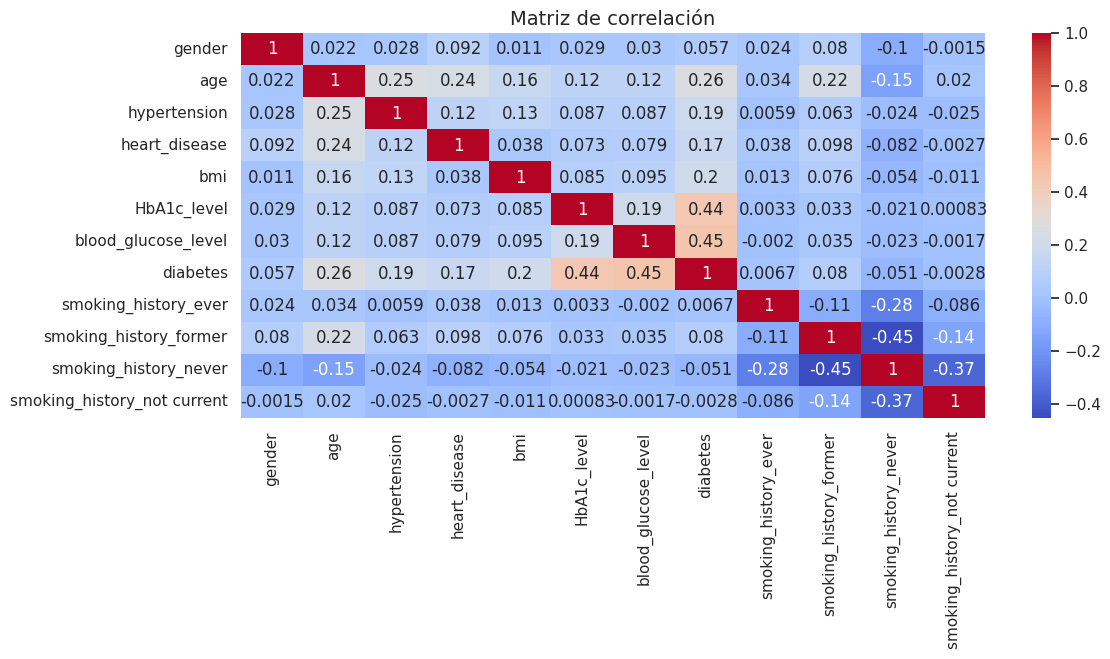

In [28]:

# Heatmap (Mapa de calor):
# Para entender la relación entre las variables
sns.heatmap(df_modificado.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [29]:
print("Columnas del dataset:")
print(df_modificado.columns.tolist())

Columnas del dataset:
['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


# Division Train/Test
En esta parte separamos las variables **predictoras** (X) de la variable **objetivo** (y) y luego dividimos los datos en dos conjuntos: uno de entrenamiento y otro de prueba. Usamos una división 80/20 y además aplicamos stratify=y para conservar la proporción de clases en ambos conjuntos.
En este caso la variable objetivo sera diabetes, que ya esta en modo binario, y las otras seran las predictoras.

In [32]:
features = [
    "gender",
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "smoking_history_ever",
    "smoking_history_former",
    "smoking_history_never",
    "smoking_history_not current"
]

X = df_modificado[features]       # conjunto de variables predictoras
y = df_modificado["diabetes"]     # variable objetivo

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,               # variables predictoras
    y,               # variable objetivo
    test_size=0.2,   # Proporcion
    random_state=42, # Semilla para reproductividad
    stratify=y       # Conserva proporciones de clases
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test :", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test :", y_test.shape)

print("\nProporción de clases en y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporción de clases en y_test:")
print(y_test.value_counts(normalize=True))

Forma de X_train: (51337, 11)
Forma de X_test : (12835, 11)
Forma de y_train: (51337,)
Forma de y_test : (12835,)

Proporción de clases en y_train:
diabetes
0    0.890196
1    0.109804
Name: proportion, dtype: float64

Proporción de clases en y_test:
diabetes
0    0.890222
1    0.109778
Name: proportion, dtype: float64


Los resultados confirman que la división del dataset se realizó correctamente. El conjunto de entrenamiento quedó con 51337 casos y el de prueba con 12835, lo que se corresponde con una partición aproximada del 80% para entrenar y 20% para evaluar.

También vemos que X_train y X_test tienen 11 columnas, porque contienen las variables predictoras seleccionadas. En cambio, y_train e y_test muestran una forma con un solo valor, ya que y es una única serie con la variable objetivo.

Lo más importante es que las proporciones de clases en entrenamiento y prueba son casi idénticas. En ambos conjuntos, la clase 0 representa alrededor del 89% y la clase 1 cerca del 10%. Esto indica que el uso de stratify=y funcionó como esperábamos: ambas particiones conservan una distribución muy similar a la del dataset original.

Esto es importante porque permite evaluar el modelo en condiciones más justas. Si una de las particiones tuviera una distribución muy distinta, los resultados podrían verse afectados no por la calidad del modelo, sino por una división poco representativa de los datos.